# 31 - TCGA-BRCA Data Preparation

This notebook prepares the TCGA-BRCA bulk RNA-seq dataset for the unlearning study.

**Data source:** CAMDA 2025 Health Privacy Challenge (Ozturk et al. 2026), downloaded from the ELSA Benchmarks platform.

**Preprocessing (by Ozturk et al.):**
1. Raw STAR counts from GDC portal via TCGAbiolinks
2. Filtered to primary tumor samples
3. Low-expression genes removed
4. DESeq2 VST normalization
5. Filtered to 978 LINCS L1000 landmark genes

**This notebook:**
1. Load and validate the pre-processed expression + subtype data
2. Map Ensembl IDs to gene symbols
3. Create train/unseen splits (85/15)
4. Define forget sets (structured, scattered, patient-level)
5. Store as AnnData for pipeline compatibility

**Dependencies:** `data/tcga_brca/TCGA-BRCA_primary_tumor_star_deseq_VST_lmgenes.tsv`, `data/tcga_brca/TCGA-BRCA_primary_tumor_subtypes.csv`, `data/tcga_brca/f1000_lm_ensembl.tsv`

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import torch
import scanpy as sc
import anndata as ad
import json
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.neighbors import NearestNeighbors

from utils import set_global_seed, GLOBAL_SEED

set_global_seed(GLOBAL_SEED)

DATA_DIR = Path('../data/tcga_brca')
OUTPUT_DIR = Path('../outputs/tcga_brca')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Seed: {GLOBAL_SEED}')

Seed: 42


## Load Expression Data

In [2]:
# Expression matrix: genes (Ensembl) x samples -> transpose to samples x genes
expr_raw = pd.read_csv(DATA_DIR / 'TCGA-BRCA_primary_tumor_star_deseq_VST_lmgenes.tsv',
                       sep='\t', index_col=0)
expr = expr_raw.T  # samples x genes
print(f'Expression: {expr.shape} (samples x genes)')
print(f'Value range: [{expr.min().min():.2f}, {expr.max().max():.2f}]')
print(f'Mean: {expr.values.mean():.2f}, Std: {expr.values.std():.2f}')
print(f'NaN count: {expr.isna().sum().sum()}')

Expression: (1089, 978) (samples x genes)
Value range: [3.11, 22.36]
Mean: 11.30, Std: 1.94
NaN count: 0


## Load Subtypes and Gene Mapping

In [3]:
# PAM50 subtypes
subtypes = pd.read_csv(DATA_DIR / 'TCGA-BRCA_primary_tumor_subtypes.csv', index_col=0)
print(f'Subtypes: {len(subtypes)} samples')
print(f'Columns: {subtypes.columns.tolist()}')
print()

# Clean subtype labels: 'BRCA.LumA' -> 'LumA'
subtypes['subtype'] = subtypes['Subtype'].str.replace('BRCA.', '', regex=False)
print('Subtype distribution:')
for s, n in subtypes['subtype'].value_counts().items():
    print(f'  {s}: {n} ({n/len(subtypes)*100:.1f}%)')

# Verify 100% overlap
assert set(expr.index) == set(subtypes.index), 'Sample mismatch!'
print(f'\nAll {len(expr)} samples have subtypes')

Subtypes: 1089 samples
Columns: ['cancer_type', 'Subtype']

Subtype distribution:
  LumA: 562 (51.6%)
  LumB: 217 (19.9%)
  Basal: 188 (17.3%)
  Her2: 82 (7.5%)
  Normal: 40 (3.7%)

All 1089 samples have subtypes


In [4]:
# Gene symbol mapping (Ensembl -> Symbol)
gene_map = pd.read_csv(DATA_DIR / 'f1000_lm_ensembl.tsv')
ens_to_sym = dict(zip(gene_map['ENSEMBL.ID'], gene_map['Symbol']))
print(f'Gene mapping: {len(ens_to_sym)} entries')

# Rename columns to gene symbols
expr.columns = [ens_to_sym.get(c, c) for c in expr.columns]
n_mapped = sum(1 for c in expr.columns if not c.startswith('ENSG'))
print(f'Mapped to symbols: {n_mapped}/{len(expr.columns)}')
print(f'Example genes: {expr.columns[:10].tolist()}')

Gene mapping: 978 entries
Mapped to symbols: 978/978
Example genes: ['TSPAN6', 'SCYL3', 'BAD', 'LAP3', 'SNX11', 'CASP10', 'CFLAR', 'FKBP4', 'RBM6', 'SLC25A13']


## Create AnnData Object

In [5]:
# Build AnnData
adata = ad.AnnData(
    X=expr.values.astype(np.float32),
    obs=pd.DataFrame({
        'sample_id': expr.index,
        'patient_id': ['-'.join(s.split('-')[:3]) for s in expr.index],
        'subtype': subtypes.loc[expr.index, 'subtype'].values,
    }, index=expr.index),
    var=pd.DataFrame({
        'gene_symbol': expr.columns,
    }, index=expr.columns),
)

print(f'AnnData: {adata.shape}')
print(f'obs columns: {adata.obs.columns.tolist()}')
print(f'Unique patients: {adata.obs["patient_id"].nunique()}')
print(f'\nSubtype counts:')
print(adata.obs['subtype'].value_counts())

AnnData: (1089, 978)
obs columns: ['sample_id', 'patient_id', 'subtype']
Unique patients: 1089

Subtype counts:
subtype
LumA      562
LumB      217
Basal     188
Her2       82
Normal     40
Name: count, dtype: int64


## Leiden Clustering

Run Leiden clustering for pipeline compatibility (existing code expects `adata.obs['leiden']`).

In [6]:
# PCA + neighbors + Leiden
sc.pp.scale(adata, max_value=10)  # scale for PCA only
sc.tl.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5, key_added='leiden')

print(f'Leiden clusters: {adata.obs["leiden"].nunique()}')
print(adata.obs['leiden'].value_counts().sort_index())

# Restore unscaled data (we scaled only for PCA)
adata.X = expr.values.astype(np.float32)

print(f'\nRestored original VST values: range [{adata.X.min():.2f}, {adata.X.max():.2f}]')

/Users/dbenson/.pyenv/versions/stat4243/lib/python3.12/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


2026-03-28 01:46:46.612866: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


/var/folders/d2/m4n149n97dn9rk26s76g_y_r0000gn/T/ipykernel_72603/3179217036.py:6: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5, key_added='leiden')


Leiden clusters: 6
leiden
0    287
1    234
2    189
3    187
4    168
5     24
Name: count, dtype: int64

Restored original VST values: range [3.11, 22.36]


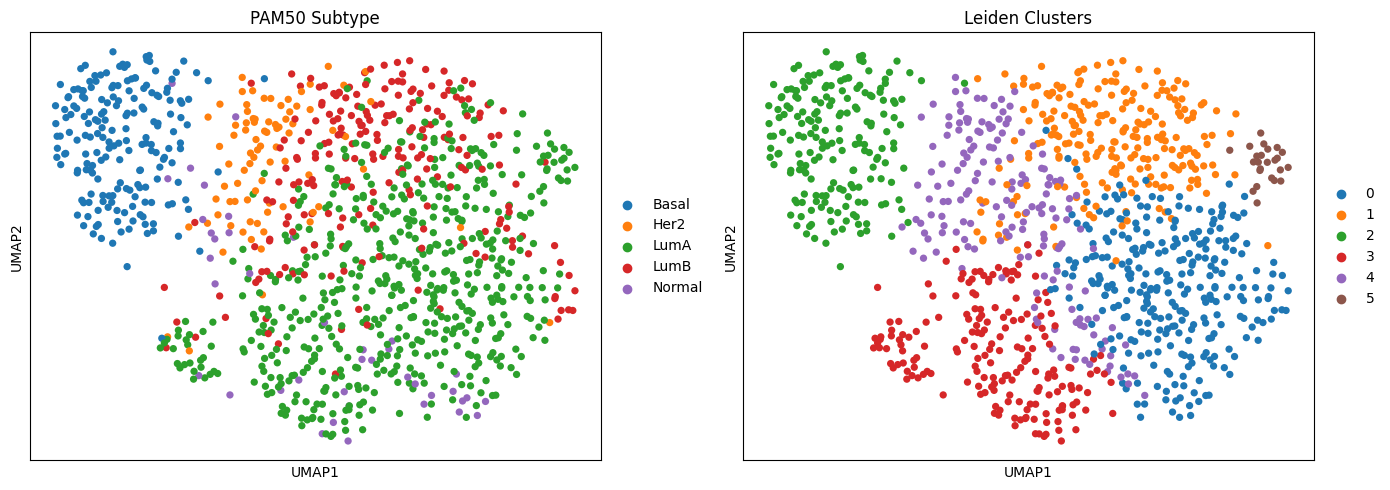

Subtype vs Leiden cluster:
leiden     0    1    2    3   4   5
subtype                            
Basal      0    1  184    1   2   0
Her2       4    9    0    3  66   0
LumA     241   85    0  153  60  23
LumB      34  138    2   19  23   1
Normal     8    1    3   11  17   0


In [7]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc.pl.umap(adata, color='subtype', ax=axes[0], show=False, title='PAM50 Subtype')
sc.pl.umap(adata, color='leiden', ax=axes[1], show=False, title='Leiden Clusters')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'umap_subtypes.png', dpi=150, bbox_inches='tight')
plt.show()

# Cross-tab: subtype vs leiden
ct = pd.crosstab(adata.obs['subtype'], adata.obs['leiden'])
print('Subtype vs Leiden cluster:')
print(ct)

## Create Splits

85/15 train/unseen split (same convention as PBMC and Tabula Muris).

In [8]:
n_cells = adata.n_obs
n_train = int(0.85 * n_cells)

np.random.seed(GLOBAL_SEED)
indices = np.arange(n_cells)
np.random.shuffle(indices)

train_indices = sorted(indices[:n_train].tolist())
unseen_indices = sorted(indices[n_train:].tolist())

print(f'Train: {len(train_indices)}, Unseen: {len(unseen_indices)}')
print(f'Train subtypes:')
for s, n in adata.obs.iloc[train_indices]['subtype'].value_counts().items():
    print(f'  {s}: {n}')
print(f'Unseen subtypes:')
for s, n in adata.obs.iloc[unseen_indices]['subtype'].value_counts().items():
    print(f'  {s}: {n}')

Train: 925, Unseen: 164
Train subtypes:
  LumA: 483
  LumB: 175
  Basal: 158
  Her2: 76
  Normal: 33
Unseen subtypes:
  LumA: 79
  LumB: 42
  Basal: 30
  Normal: 7
  Her2: 6


## Define Forget Sets

Three types:
1. **Structured** - All Basal patients in training set (biologically distinct, ER-negative)
2. **Scattered** - 30 random patients from training set
3. **Patient-level** - Small groups of patients (5, 10, 20) for patient-level unlearning

In [9]:
# Structured: all Basal patients in training set
train_set = set(train_indices)
basal_mask = adata.obs['subtype'] == 'Basal'
basal_indices = np.where(basal_mask)[0]
forget_structured = sorted(int(i) for i in basal_indices if i in train_set)
retain_structured = sorted(int(i) for i in train_indices if i not in set(forget_structured))

print(f'Structured forget set (Basal patients):')
print(f'  Forget: {len(forget_structured)}')
print(f'  Retain: {len(retain_structured)}')
print(f'  Unseen: {len(unseen_indices)}')

split_structured = {
    'forget_indices': forget_structured,
    'retain_indices': retain_structured,
    'unseen_indices': unseen_indices,
    'n_forget': len(forget_structured),
    'n_retain': len(retain_structured),
    'n_unseen': len(unseen_indices),
    'forget_type': 'structured',
    'forget_subtype': 'Basal',
    'description': 'Structured forget set: all Basal patients in training set'
}

with open(OUTPUT_DIR / 'split_structured.json', 'w') as f:
    json.dump(split_structured, f, indent=2)
print(f'Saved split_structured.json')

Structured forget set (Basal patients):
  Forget: 158
  Retain: 767
  Unseen: 164
Saved split_structured.json


In [10]:
# Scattered: 30 random patients from training set
np.random.seed(GLOBAL_SEED)
forget_scattered = sorted(np.random.choice(train_indices, size=30, replace=False).tolist())
retain_scattered = sorted([i for i in train_indices if i not in set(forget_scattered)])

split_scattered = {
    'forget_indices': forget_scattered,
    'retain_indices': retain_scattered,
    'unseen_indices': unseen_indices,
    'n_forget': len(forget_scattered),
    'n_retain': len(retain_scattered),
    'n_unseen': len(unseen_indices),
    'forget_type': 'scattered',
    'description': 'Scattered forget set: 30 random patients'
}

with open(OUTPUT_DIR / 'split_scattered.json', 'w') as f:
    json.dump(split_scattered, f, indent=2)
print(f'Scattered forget set: {len(forget_scattered)} patients')
print(f'Saved split_scattered.json')

Scattered forget set: 30 patients
Saved split_scattered.json


In [11]:
# Patient-level: groups of 5, 10, 20 Basal patients
np.random.seed(GLOBAL_SEED)
basal_train = [int(i) for i in forget_structured]  # all Basal in training
np.random.shuffle(basal_train)

for n_patients in [5, 10, 20]:
    forget = sorted(basal_train[:n_patients])
    retain = sorted(i for i in train_indices if i not in set(forget))
    patient_ids = [str(adata.obs.iloc[i]['patient_id']) for i in forget]
    
    split = {
        'forget_indices': forget,
        'retain_indices': retain,
        'unseen_indices': unseen_indices,
        'n_forget': len(forget),
        'n_retain': len(retain),
        'n_unseen': len(unseen_indices),
        'forget_type': 'patient_level',
        'patient_ids': patient_ids,
        'description': f'Patient-level forget set: {n_patients} Basal patients'
    }
    
    fname = f'split_patient_{n_patients}.json'
    with open(OUTPUT_DIR / fname, 'w') as f:
        json.dump(split, f, indent=2)
    print(f'Patient-level n={n_patients}: {len(forget)} patients, saved {fname}')

Patient-level n=5: 5 patients, saved split_patient_5.json
Patient-level n=10: 10 patients, saved split_patient_10.json
Patient-level n=20: 20 patients, saved split_patient_20.json


## Save Processed Data

In [12]:
# Save AnnData
save_path = DATA_DIR / 'tcga_brca_processed.h5ad'
adata.write(save_path)
print(f'Saved: {save_path}')
print(f'Shape: {adata.shape}')
print(f'obs columns: {adata.obs.columns.tolist()}')
print(f'var columns: {adata.var.columns.tolist()}')

Saved: ../data/tcga_brca/tcga_brca_processed.h5ad
Shape: (1089, 978)
obs columns: ['sample_id', 'patient_id', 'subtype', 'leiden']
var columns: ['gene_symbol', 'mean', 'std']


## Summary

| Output | Path |
|--------|------|
| Processed AnnData | `data/tcga_brca/tcga_brca_processed.h5ad` |
| Structured split (Basal) | `outputs/tcga_brca/split_structured.json` |
| Scattered split (random 30) | `outputs/tcga_brca/split_scattered.json` |
| Patient-level splits | `outputs/tcga_brca/split_patient_{5,10,20}.json` |
| UMAP visualization | `outputs/tcga_brca/umap_subtypes.png` |

**Data provenance:** Ozturk et al. (2026), CAMDA 2025 Health Privacy Challenge. TCGA-BRCA STAR counts from GDC, VST-normalized, 978 L1000 landmark genes. See `data/tcga_brca/data_provenance.json`.

**Next:** `32_tcga_brca_baseline.ipynb` - Train baseline VAE and evaluate MIA